# Name : Muhammad Hassan Khalid
# 21L-5692

# TASK A

# Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading the data in a csv file

In [2]:
data = pd.read_csv('Mall_Customers.csv')

## Data Shape

In [3]:
print("Shape:", data.shape)

Shape: (200, 5)


## Data Features

In [4]:
print("\nFeatures:", data.columns)


Features: Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


## Data Description

In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Information

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Visualizing some data points

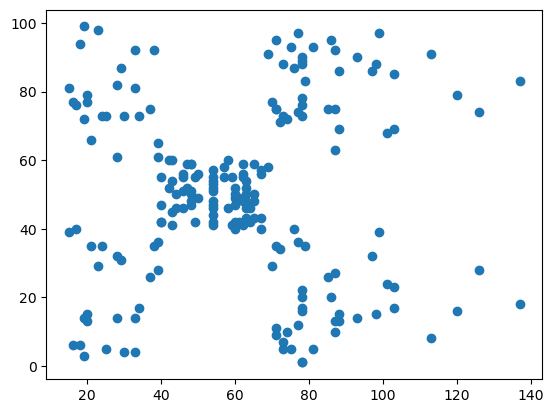

In [7]:
x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

plt.scatter(x, y)

plt.show()

# Elbow Method

D:\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


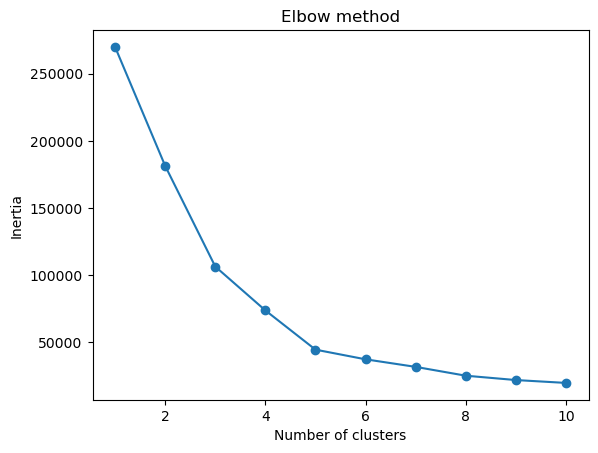

In [8]:
from sklearn.cluster import KMeans

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Visualize the result

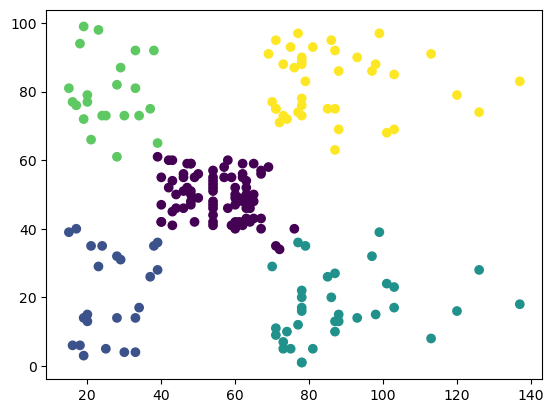

In [9]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)

plt.show()

# TASK B

# Importing Libraires

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns

In [107]:
data = pd.read_csv('Mall_Customers.csv')

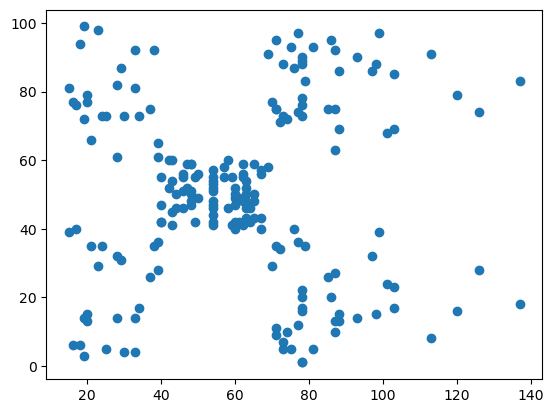

In [108]:
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])

## Selecting random centroids

In [124]:
k=5
Centroids = (data.sample(n=k))
Centroids

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),1,2,3,4,5,...,192,193,194,195,196,197,198,199,200,Clust
165,166,Female,36,85,75,69.296465,55.154329,12.727922,74.953319,14.142136,...,36.769553,79.195959,11.313708,15.556349,89.095454,113.137085,50.911688,2.828427,19.798990,130
108,109,Male,68,63,43,38.183766,24.041631,18.384776,43.840620,16.970563,...,5.656854,48.083261,19.798990,15.556349,57.982756,82.024387,19.798990,28.284271,11.313708,42
44,45,Female,49,39,28,4.242641,9.899495,52.325902,9.899495,50.911688,...,28.284271,14.142136,53.740115,49.497475,24.041631,48.083261,14.142136,62.225397,45.254834,42
128,129,Male,59,71,11,49.497475,35.355339,7.071068,55.154329,5.656854,...,16.970563,59.396970,8.485281,4.242641,69.296465,93.338095,31.112698,16.970563,0.000000,42
59,60,Male,53,46,46,14.142136,0.000000,42.426407,19.798990,41.012193,...,18.384776,24.041631,43.840620,39.597980,33.941125,57.982756,4.242641,52.325902,35.355339,42


## Plotting centroids on scatter

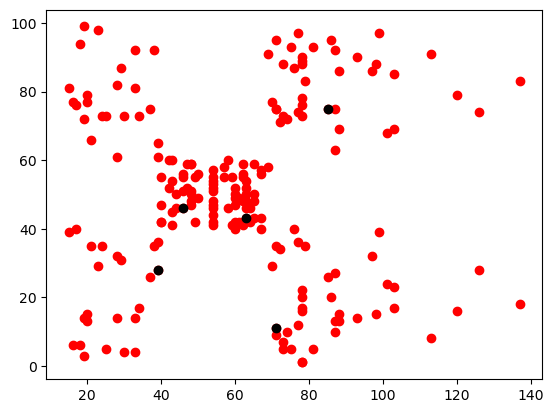

In [125]:
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'],c='r')
plt.scatter(Centroids['Annual Income (k$)'],Centroids['Spending Score (1-100)'],c='k')

## Calculating difference + new centroids by taking mean

In [126]:
diff=1
j=0
while(diff!=0):
    X=data
    i=1
    for index1,row_c in Centroids.iterrows():
        ED=[]
        for index2,row_d in X.iterrows():
            d1=(row_c["Spending Score (1-100)"]-row_d["Annual Income (k$)"])**2
            d2=(row_c["Spending Score (1-100)"]-row_d["Annual Income (k$)"])**2
            d=sqrt(d1+d2)
            ED.append(d)
        data[i]=ED
        i=i+1
    C=[]
    for index,row in data.iterrows():
        min_dist=row[1]
        pos=1
        for i in range(k):
            if row[i+1]<min_dist:
                min_dist=row[i+1]
                pos=i+1
            C.append(pos)
        data["Clust"]=C
        Centroids_new=data.groupby(["Clust"]).mean()[["Annual Income (k$)","Spending Score (1-100)"]]
        if j==0:
            diff=1
            j=j+1
        else:
            diff=(Centroids_new['Annual Income (k$)']-Centroids['Annual Income (k$)']).sum()+Centroids_new['Spending Score (1-100)']
            print(diff.sum())
        Centroids=data.groupby(["Clust"].mean()[["Annual Income (k$)","Spending Score (1-100)"]])

ValueError: Length of values (5) does not match length of index (200)

In [122]:
Centroids

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),1,2,3,4,5
42,43,Male,48,39,36,5.656854,4.242641,33.941125,16.970563,31.112698
113,114,Male,19,64,46,29.698485,31.112698,1.414214,52.325902,66.468037
153,154,Female,38,78,76,49.497475,50.911688,21.213203,72.124892,86.267027
180,181,Female,37,97,32,76.367532,77.781746,48.083261,98.994949,113.137085
129,130,Male,38,71,75,39.597980,41.012193,11.313708,62.225397,76.367532
...,...,...,...,...,...,...,...,...,...,...
148,149,Female,34,78,22,49.497475,50.911688,21.213203,72.124892,86.267027
162,163,Male,19,81,5,53.740115,55.154329,25.455844,76.367532,90.509668
72,73,Female,60,50,49,9.899495,11.313708,18.384776,32.526912,46.669048
161,162,Female,29,79,83,50.911688,52.325902,22.627417,73.539105,87.681241


## Print final cluster

In [123]:
color=['b','g','k']
for l in range(k):
    XD=data[data["Clust"]==l+1]
    plt.scatter(XD["Spending Score (1-100)"],XD["Annual Income (k$)"],c=color[k])
plt.scatter(Centroids["Spending Score (1-100)"],Centroids["Annual Income (k$)"],c='r')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

IndexError: list index out of range